In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [2]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [3]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(9864, 26)
(2466, 26)
(9864, 1)
(2466, 1)


In [4]:
#Construccion de la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
#arquitectura
model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(26,)
    ),
    
    Dense(
        32,
        activation="relu"
    ),
    
    Dense(
        1,
        activation="sigmoid"
    )
])

d:\Universidad\Tecnologias Emergentes I\Repositorio_tI26-Espada-Ugarte\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
#probamos compialcion
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8616 - loss: 0.3361 - val_accuracy: 0.8880 - val_loss: 0.2769
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.8935 - loss: 0.2604 - val_accuracy: 0.8936 - val_loss: 0.2626
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.8991 - loss: 0.2437 - val_accuracy: 0.8900 - val_loss: 0.2621
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.9022 - loss: 0.2344 - val_accuracy: 0.8946 - val_loss: 0.2529
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.9039 - loss: 0.2295 - val_accuracy: 0.8925 - val_loss: 0.2503
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - accuracy: 0.9070 - loss: 0.2240 - val_accuracy: 0.8976 - val_loss: 0.2514
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.9084 - loss: 0.2191 - val_accuracy: 0.8910 - val_loss: 0.2521
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.9102 - loss: 0.2161 - va

In [9]:
#curva entrenamiento
import matplotlib.pyplot as plt

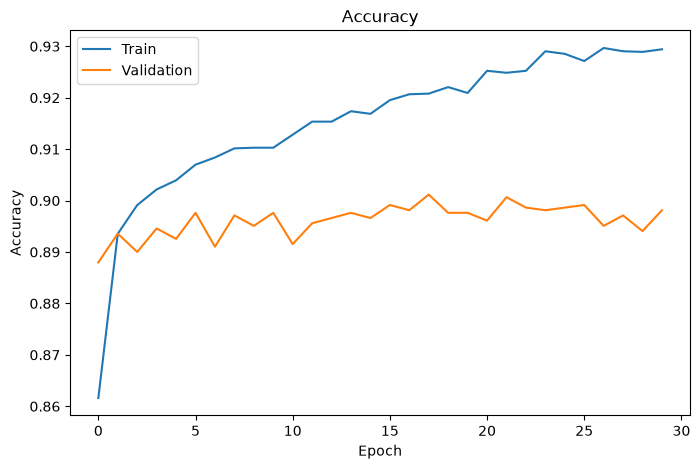

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

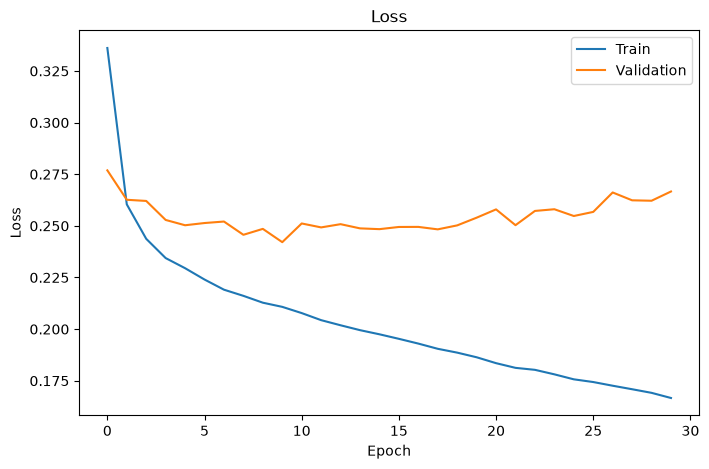

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [12]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.8816 - loss: 0.2849
Accuracy: 0.8815895915031433


In [13]:
y_pred_prob = model.predict(X_test)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


In [14]:
#metricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      2084
           1       0.63      0.55      0.59       382

    accuracy                           0.88      2466
   macro avg       0.78      0.75      0.76      2466
weighted avg       0.88      0.88      0.88      2466



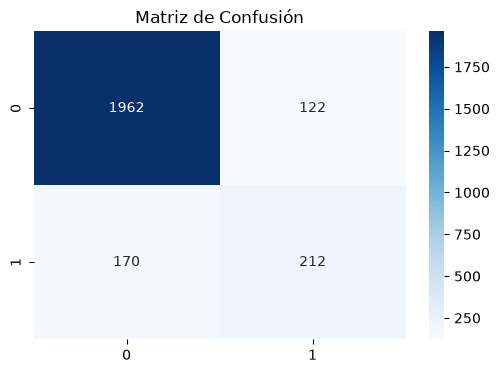

In [15]:
#matriz de confusion
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Matriz de Confusión"
)

plt.show()

In [16]:
#segunda prueba con la clase (class weights)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values.ravel()
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.5915087550971456), 1: np.float64(3.2319790301441675)}


In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8821 - loss: 0.2606 - val_accuracy: 0.8510 - val_loss: 0.3392
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.8909 - loss: 0.2398 - val_accuracy: 0.8125 - val_loss: 0.4044
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.8957 - loss: 0.2339 - val_accuracy: 0.8485 - val_loss: 0.3632
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - accuracy: 0.8908 - loss: 0.2285 - val_accuracy: 0.8550 - val_loss: 0.3568
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8977 - loss: 0.2243 - val_accuracy: 0.8429 - val_loss: 0.3604
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8981 - loss: 0.2201 - val_accuracy: 0.8510 - val_loss: 0.3503
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.9000 - loss: 0.2184 - val_accuracy: 0.8500 - val_loss: 0.3690
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8979 - loss: 0.2132 - val_accu

In [18]:
#verificamos
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.8463 - loss: 0.4260
Accuracy: 0.8463098406791687


In [19]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2084
           1       0.50      0.73      0.60       382

    accuracy                           0.85      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.85      0.86      2466

